In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [ ]:
#remote agent
# eval "$(ssh-agent -s)"
# ssh-add ~/.ssh/id_ed25519
#ssh -T git@github.com
#git remote set-url origin git@github.com:paulaliv/AAA_project.git

In [3]:
remote = True

In [4]:
if remote:
    plasma_dir = r"/scratch/bmep/plalfken/Venkat/plasma_data.xlsx"
    tissue_dir= r"/scratch/bmep/plalfken/Venkat/tissue/tissue_data.xlsx"
else:
    plasma_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\plasma_data.xlsx"
    plasma_labels_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\Proteomics sample labels.csv"
    plasma_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\20241126 Sample ordering and info.xlsx"


    tissue_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\tissue_data.xlsx"
    tissue_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\Clinical Data MACE Amsterdam VA.xlsx"

In [5]:
tissue_data = pd.read_excel(tissue_dir)
tissue_data.head()

,Unnamed: 0,Protein.Group,Protein.Names,Genes,S001,S002,S003,S004,S007,S011,...,S079,S080,S081,S087,S091,S093,S095,Log2 intensity OPL3026_HeLa50ng_07,S006,S084
0,0,Q16585,SGCB_HUMAN,SGCB,9.065723,8.804035,10.121942,8.103925,7.547642,8.372846,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,P51608-2,MECP2_HUMAN,MECP2,9.233215,8.649819,10.810051,9.461354,8.213499,9.181561,...,6.590036,NaN,7.613278,5.974929,NaN,6.578975,NaN,8.069332,6.773532,6.396201
2,2,Q9H3H3,CK068_HUMAN,C11orf68,9.866450,9.624528,8.357053,9.350256,8.462160,9.632663,...,8.897010,NaN,NaN,7.205819,NaN,7.817692,NaN,9.130469,6.774161,7.462926
3,3,Q6ZT12;Q6ZT12-4,UBR3_HUMAN,UBR3,7.386442,7.298594,7.382471,7.472147,NaN,7.684338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.340680,NaN,NaN
4,4,Q96P70,IPO9_HUMAN,IPO9,9.011502,9.441655,8.578271,9.246102,8.908170,9.363126,...,8.814127,6.376397,6.931440,7.439738,8.585849,8.410148,6.14147,10.378998,6.955465,8.932941


### Match tissue and plasma samples

In [6]:
plasma_data = pd.read_excel(plasma_dir)
matched_samples = [sample for sample in plasma_data.columns[1:] if sample in tissue_data.columns[1:]]
print(matched_samples)
print(len(matched_samples))

['Genes', 'S001', 'S002', 'S003', 'S004', 'S005', 'S060', 'S006', 'S007', 'S008', 'S009', 'S062', 'S010', 'S011', 'S021', 'S012', 'S013', 'S063', 'S014', 'S015', 'S023', 'S016', 'S017', 'S064', 'S018', 'S019', 'S026', 'S020', 'S022', 'S024', 'S025', 'S030', 'S053', 'S032', 'S033', 'S067', 'S034', 'S036', 'S068', 'S038', 'S039', 'S041', 'S069', 'S043', 'S091', 'S045', 'S070', 'S046', 'S047', 'S092', 'S048', 'S049', 'S071', 'S050', 'S093', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074', 'S080', 'S081', 'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072', 'S082', 'S035', 'S078', 'S077', 'S095', 'S029', 'S037', 'S079', 'S061', 'S066', 'S031', 'S052', 'S076', 'S083', 'S087', 'S090']
86


In [8]:
print(plasma_data.shape)
tissue_data.shape

(1896, 87)


(9726, 108)

In [9]:
tissue_data = tissue_data[matched_samples]
tissue_data.shape

(9726, 86)

In [10]:
print(tissue_data.head(3))
assert tissue_data['Genes'].duplicated().sum() == 0, "Duplicate genes found!"

      Genes      S001      S002       S003      S004      S005      S060  \
0      SGCB  9.065723  8.804035  10.121942  8.103925       NaN  8.065864   
1     MECP2  9.233215  8.649819  10.810051  9.461354       NaN  8.902014   
2  C11orf68  9.866450  9.624528   8.357053  9.350256  7.244485  8.987253   

       S006      S007  S008  ...      S037      S079      S061       S066  \
0       NaN  7.547642   NaN  ...       NaN       NaN  7.716582   9.815781   
1  6.773532  8.213499   NaN  ...  6.795767  6.590036  9.119543  10.138644   
2  6.774161  8.462160   NaN  ...  7.354149  8.897010  9.642071  10.768965   

        S031       S052      S076      S083      S087      S090  
0   8.089769   8.689987  8.068925  7.908268       NaN  7.897971  
1  10.681024   9.247457  9.806662  8.980158  5.974929  8.783248  
2   9.794970  10.156753  9.598489  9.796257  7.205819  7.864589  

[3 rows x 86 columns]


AssertionError: Duplicate genes found!

In [8]:
unique_proteins = tissue_data['Genes'].unique()
print(tissue_data.shape)
print(len(unique_proteins))

(9726, 108)
9412


### Handling Gene Duplicates
Keep for Data exploration, for modelling, do df_gene = df.groupby("Gene").median() or keep the most abundant entry


### Global Missingness
Separate features from metadata

In [11]:
gene_symbols = tissue_data['Genes']
expression_matrix = tissue_data.drop(columns=['Genes']) 

In [12]:
print("=== Global Missingness ===")
print(f"Total missing values: {expression_matrix.isnull().sum().sum()}")
print(f"Percentage missing: {expression_matrix.isnull().mean().mean()*100:.2f}%")

=== Global Missingness ===
Total missing values: 306534
Percentage missing: 37.08%


### Protein-level missingness


Top 5 proteins with most missing data:
9706    1.0
9277    1.0
9279    1.0
9253    1.0
530     1.0
9704    1.0
9312    1.0
9313    1.0
4893    1.0
9721    1.0
20      1.0
9722    1.0
8801    1.0
8816    1.0
8858    1.0
5482    1.0
3461    1.0
3453    1.0
6563    1.0
6909    1.0
6905    1.0
6513    1.0
6950    1.0
6954    1.0
6494    1.0
6493    1.0
6979    1.0
9664    1.0
7364    1.0
7383    1.0
9636    1.0
9635    1.0
6417    1.0
7111    1.0
6410    1.0
2907    1.0
6376    1.0
8709    1.0
5040    1.0
8769    1.0
4508    1.0
8780    1.0
8798    1.0
8811    1.0
8845    1.0
4551    1.0
574     1.0
9222    1.0
9217    1.0
9211    1.0
dtype: float64


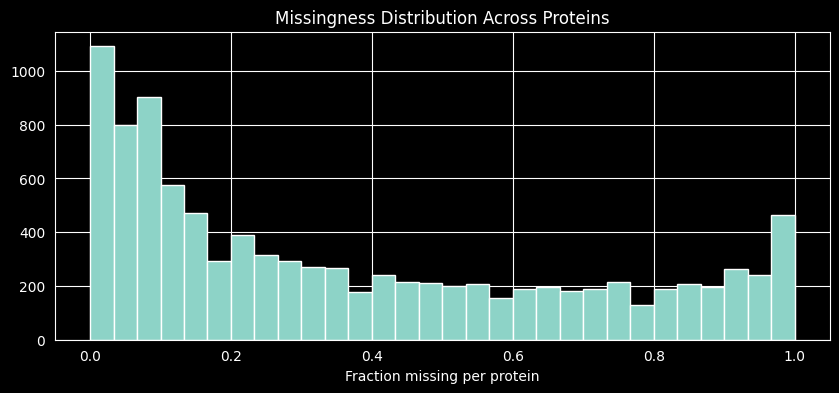

In [13]:
protein_missingness = tissue_data.iloc[:, 1:].isnull().mean(axis=1)
print("\nTop 5 proteins with most missing data:")
print(protein_missingness.sort_values(ascending=False).head(50))

# Visualize
plt.figure(figsize=(10,4))
protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Proteins")
plt.xlabel("Fraction missing per protein")
plt.show()

In [14]:
protein_missingness = tissue_data.iloc[:, 3:].isnull().mean(axis=1) * 100

missingness_df = pd.DataFrame({
    'protein': tissue_data.iloc[:, 3],  
    'missingness_percentage': protein_missingness
})

missingness_df.to_csv('tissue_protein_missingness.csv', index=False)

print(missingness_df.head())

     protein  missingness_percentage
0  10.121942               19.277108
1  10.810051                6.024096
2   8.357053                7.228916
3   7.382471               34.939759
4   8.578271                0.000000


### Patient-Level Missingness


Top 5 patients with most missing data:
S081    0.932860
S091    0.838885
S095    0.836726
S008    0.834567
S080    0.826650
dtype: float64


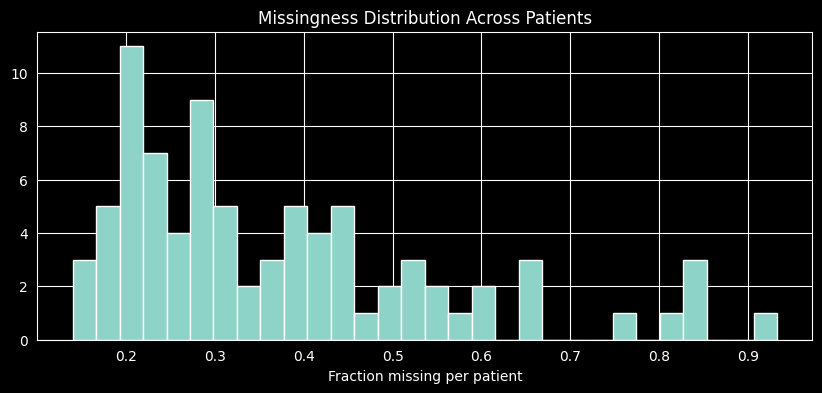

In [15]:
patient_missingness = tissue_data.iloc[:, 3:].isnull().mean(axis=0)
print("\nTop 5 patients with most missing data:")
print(patient_missingness.sort_values(ascending=False).head())

plt.figure(figsize=(10,4))
patient_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

In [16]:
patient_missingness = tissue_data.iloc[:, 1:].isnull().mean(axis=0) * 100

missingness_sample_df = pd.DataFrame({
    'sample': tissue_data.columns[1:],
    'missingness_percentage': patient_missingness
})

missingness_sample_df.to_csv('tissue_sample_missingness.csv', index=False)

print("\nTop 10 samples with most missing data:")
print(missingness_sample_df.sort_values(by='missingness_percentage', ascending=False).head(10))



Top 10 samples with most missing data:
     sample  missingness_percentage
S081   S081               93.286037
S091   S091               83.888546
S095   S095               83.672630
S008   S008               83.456714
S080   S080               82.665022
S006   S006               75.385564
S009   S009               66.625540
S087   S087               66.317088
S005   S005               66.306806
S093   S093               60.610734


In [49]:
plasma_data.columns

Index(['Unnamed: 0', 'Genes', 'S001', 'S002', 'S003', 'S004', 'S005', 'S060',
       'S006', 'S007', 'S008', 'S009', 'S062', 'S010', 'S011', 'S021', 'S012',
       'S013', 'S063', 'S014', 'S015', 'S023', 'S016', 'S017', 'S064', 'S018',
       'S019', 'S026', 'S020', 'S022', 'S024', 'S025', 'S030', 'S053', 'S032',
       'S033', 'S067', 'S034', 'S036', 'S068', 'S038', 'S039', 'S041', 'S069',
       'S043', 'S091', 'S045', 'S070', 'S046', 'S047', 'S092', 'S048', 'S049',
       'S071', 'S050', 'S093', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074',
       'S080', 'S081', 'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072',
       'S082', 'S035', 'S078', 'S077', 'S095', 'S029', 'S037', 'S079', 'S061',
       'S066', 'S031', 'S052', 'S076', 'S083', 'S087', 'S090'],
      dtype='str')

#### Patient-level missingness (only matched data)

(9726, 86)

Top 10 patients with most missing data:
S081    0.932860
S091    0.838885
S095    0.836726
S008    0.834567
S080    0.826650
S006    0.753856
S009    0.666255
S087    0.663171
S005    0.663068
S093    0.606107
dtype: float64


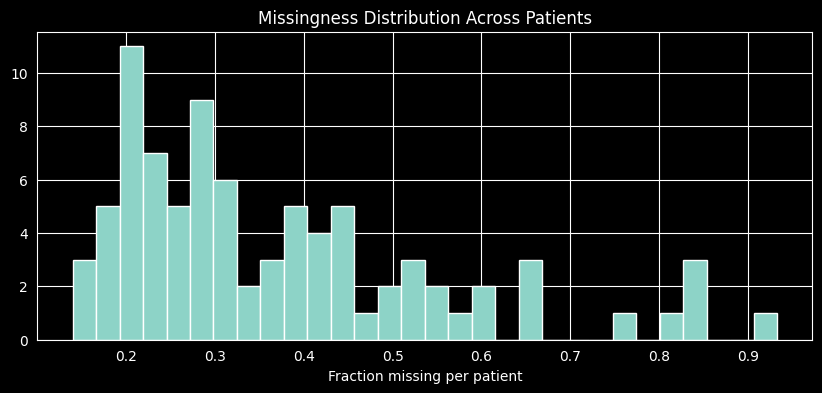

In [17]:
tissue_data_matched = tissue_data[matched_samples]
print(tissue_data_matched.shape)
patient_missingness_matched = tissue_data_matched.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 10 patients with most missing data:")
print(patient_missingness_matched.sort_values(ascending=False).head(10))

plt.figure(figsize=(10,4))
patient_missingness_matched.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

### Remove Samples with high missingness
Patients with high missingness can artifically inflate protein missingness

In [91]:
# # Dynamic threshold - keep at least 70 patients (adjust as needed)
# target_keep_patients = 75
# q = (tissue_data.shape[1] - 1/target_keep_patients)
# print(q)
# patient_threshold = np.percentile(patient_missingness_matched, q)
#
# removed_patients = patient_missingness_matched[patient_missingness_matched > patient_threshold].index.tolist()
# good_patients = patient_missingness_matched[patient_missingness_matched <= patient_threshold].index
#
# filtered_by_patient = tissue_data[['Genes'] + good_patients.tolist()]
#
# print(f"\n=== PATIENT FILTERING ===")
# print(f"Used adaptive threshold: {patient_threshold:.1%} missing")
# print(f"Removed {len(removed_patients)} patients: {removed_patients}")
# print(f"Retained {len(good_patients)} patients")

85.98666666666666

=== PATIENT FILTERING ===
Used adaptive threshold: 56.0% missing
Removed 12 patients: ['S005', 'S006', 'S008', 'S009', 'S016', 'S091', 'S093', 'S080', 'S081', 'S095', 'S037', 'S087']
Retained 73 patients


In [68]:
print(filtered_by_patient.shape)

(9726, 74)


Problem is, not the same samples are removed for plasma and tissue proteins

In [18]:
plasma_data = plasma_data[matched_samples]
print(plasma_data.shape)

(1896, 86)


In [50]:
target_keep_patients = 75 
q = (tissue_data.shape[1] - 1/target_keep_patients)
print(q)

patient_missingness_plasma = plasma_data.iloc[:, 1:].isnull().mean(axis=0)* 100
print("\nPLASMA: Top 10 patients with most missing data:")
print(patient_missingness_plasma.sort_values(ascending=False).head(10))
print('TISSUE: Top 10 samples with most missing data:')
print(patient_missingness.sort_values(ascending=False).head(10))


patient_threshold = np.percentile(patient_missingness, q)
print(patient_threshold)
# 
removed_patients_tissue = patient_missingness[patient_missingness > patient_threshold].index.tolist()
good_patients_tissue = patient_missingness[patient_missingness<= patient_threshold].index

removed_patients_plasma = patient_missingness_plasma[patient_missingness_plasma > patient_threshold].index.tolist()
good_patients_plasma = patient_missingness_plasma[patient_missingness_plasma <= patient_threshold].index.tolist()

tissue_data_filtered = tissue_data[['Genes'] + good_patients_tissue.tolist()]
tissue_data_filtered = tissue_data_filtered.drop(columns=[removed_patients_plasma[0]])
plasma_data_filtered = plasma_data[['Genes'] + good_patients_tissue.tolist()]
plasma_data_filtered = plasma_data_filtered.drop(columns=[removed_patients_plasma[0]])

print(f"\n=== PATIENT FILTERING ===")
print(f"Used adaptive threshold: {patient_threshold.round(2)}% missing")
print(f"TISSUE: Removed {len(removed_patients_tissue)} patients: {removed_patients_tissue}")
print(f"Retained {len(good_patients_tissue)} patients")
print(f'PLASMA: Removed {len(removed_patients_plasma)}: {removed_patients_plasma}')
print(f"Retained {tissue_data_filtered.shape[1]-1} patients")
print(tissue_data_filtered.columns)

85.98666666666666

PLASMA: Top 10 patients with most missing data:
S046    59.704641
S052    55.854430
S057    52.689873
S090    49.789030
S067    48.681435
S031    46.940928
S071    45.200422
S035    44.725738
S068    44.409283
S050    41.666667
dtype: float64
TISSUE: Top 10 samples with most missing data:
S081    93.286037
S091    83.888546
S095    83.672630
S008    83.456714
S080    82.665022
S006    75.385564
S009    66.625540
S087    66.317088
S005    66.306806
S093    60.610734
dtype: float64
56.043972856261576

=== PATIENT FILTERING ===
Used adaptive threshold: 56.04% missing
TISSUE: Removed 12 patients: ['S005', 'S006', 'S008', 'S009', 'S016', 'S091', 'S093', 'S080', 'S081', 'S095', 'S037', 'S087']
Retained 73 patients
PLASMA: Removed 1: ['S046']
Retained 72 patients
Index(['Genes', 'S001', 'S002', 'S003', 'S004', 'S060', 'S007', 'S062', 'S010',
       'S011', 'S021', 'S012', 'S013', 'S063', 'S014', 'S015', 'S023', 'S017',
       'S064', 'S018', 'S019', 'S026', 'S020', 'S022', 

In [54]:
protein_missingness = tissue_data_filtered.iloc[:, 1:].isnull().mean(axis=1)

MIN_DATA_PRESENCE = 0.80
protein_threshold = 1 - MIN_DATA_PRESENCE

good_proteins = protein_missingness[protein_missingness <= protein_threshold].index
removed_proteins = protein_missingness[protein_missingness > protein_threshold].index.tolist()

tissue_data_filtered_final = tissue_data_filtered.loc[good_proteins]

print(f"\n=== PROTEIN FILTERING ===")
print(f"Threshold: ≥{MIN_DATA_PRESENCE:.0%} data presence (≤{protein_threshold:.0%} missing)")
print(f"Removed {len(removed_proteins)} proteins with low data presence")
print(f"Retained {len(good_proteins)} proteins")

tissue_data_filtered_final.to_csv('tissue_data_filtered.csv', index=False)



=== PROTEIN FILTERING ===
Threshold: ≥80% data presence (≤20% missing)
Removed 4599 proteins with low data presence
Retained 5127 proteins


In [55]:
protein_missingness_plasma = plasma_data_filtered.iloc[:, 1:].isnull().mean(axis=1)

MIN_DATA_PRESENCE = 0.80
protein_threshold = 1 - MIN_DATA_PRESENCE

good_proteins = protein_missingness_plasma[protein_missingness_plasma <= protein_threshold].index
removed_proteins = protein_missingness_plasma[protein_missingness_plasma > protein_threshold].index.tolist()

plasma_data_filtered_final = plasma_data_filtered.loc[good_proteins]

print(f"\n=== PROTEIN FILTERING PLASMA ===")
print(f"Threshold: ≥{MIN_DATA_PRESENCE:.0%} data presence (≤{protein_threshold:.0%} missing)")
print(f"Removed {len(removed_proteins)} proteins with low data presence")
print(f"Retained {len(good_proteins)} proteins")

plasma_data_filtered_final.to_csv('plasma_data_filtered.csv', index=False)



=== PROTEIN FILTERING PLASMA ===
Threshold: ≥80% data presence (≤20% missing)
Removed 812 proteins with low data presence
Retained 1084 proteins



Top 10 patients with most missing data:
S032    0.226109
S067    0.209693
S090    0.185265
S079    0.178816
S033    0.168263
S053    0.159859
S078    0.159273
S094    0.122533
S039    0.112761
S074    0.110025
dtype: float64


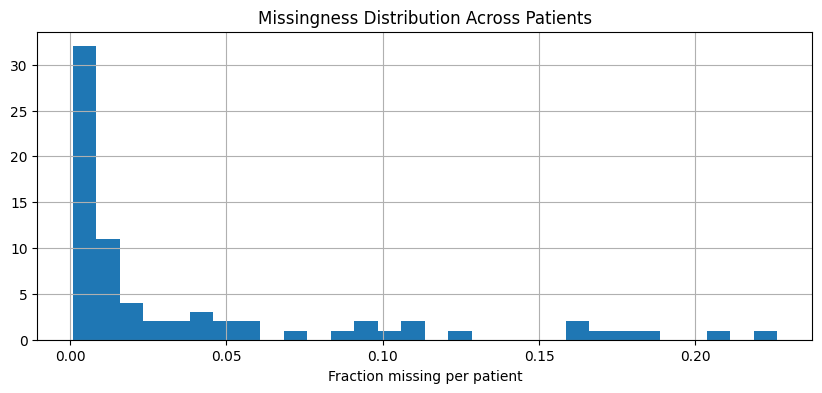

In [94]:

patient_missingness_matched = tissue_data_filtered_final.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 10 patients with most missing data:")
print(patient_missingness_matched.sort_values(ascending=False).head(10))

plt.figure(figsize=(10,4))
patient_missingness_matched.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()


Top 5 proteins with most missing data:
9583    0.191781
9459    0.191781
9170    0.191781
9167    0.191781
9040    0.191781
8740    0.191781
8678    0.191781
8667    0.191781
8536    0.191781
8498    0.191781
8487    0.191781
8413    0.191781
8310    0.191781
8280    0.191781
8277    0.191781
8225    0.191781
8147    0.191781
7877    0.191781
7742    0.191781
7721    0.191781
7612    0.191781
7419    0.191781
7248    0.191781
7227    0.191781
7131    0.191781
7097    0.191781
7007    0.191781
6900    0.191781
6834    0.191781
6828    0.191781
6821    0.191781
6807    0.191781
6654    0.191781
6599    0.191781
6538    0.191781
6475    0.191781
6329    0.191781
6317    0.191781
6311    0.191781
6271    0.191781
6209    0.191781
5974    0.191781
5936    0.191781
5932    0.191781
5921    0.191781
5828    0.191781
5794    0.191781
5717    0.191781
5659    0.191781
5626    0.191781
dtype: float64


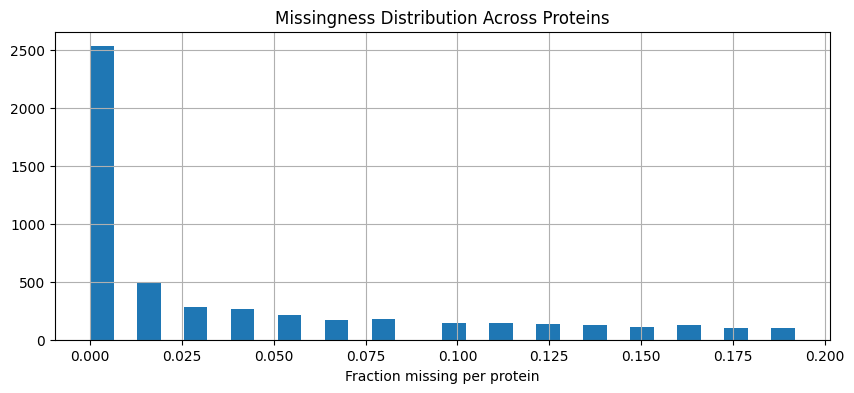

In [95]:
protein_missingness = tissue_data_filtered_final.iloc[:, 1:].isnull().mean(axis=1)
print("\nTop 5 proteins with most missing data:")
print(protein_missingness.sort_values(ascending=False).head(50))

# Visualize
plt.figure(figsize=(10,4))
protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Proteins")
plt.xlabel("Fraction missing per protein")
plt.show()

#### Intensity vs Missingness analysis

In [61]:
print(tissue_data[2:].columns)

Index(['Genes', 'S001', 'S002', 'S003', 'S004', 'S005', 'S060', 'S006', 'S007',
       'S008', 'S009', 'S062', 'S010', 'S011', 'S021', 'S012', 'S013', 'S063',
       'S014', 'S015', 'S023', 'S016', 'S017', 'S064', 'S018', 'S019', 'S026',
       'S020', 'S022', 'S024', 'S025', 'S030', 'S053', 'S032', 'S033', 'S067',
       'S034', 'S036', 'S068', 'S038', 'S039', 'S041', 'S069', 'S043', 'S091',
       'S045', 'S070', 'S046', 'S047', 'S092', 'S048', 'S049', 'S071', 'S050',
       'S093', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074', 'S080', 'S081',
       'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072', 'S082', 'S035',
       'S078', 'S077', 'S095', 'S029', 'S037', 'S079', 'S061', 'S066', 'S031',
       'S052', 'S076', 'S083', 'S087', 'S090'],
      dtype='object')


(9726,)


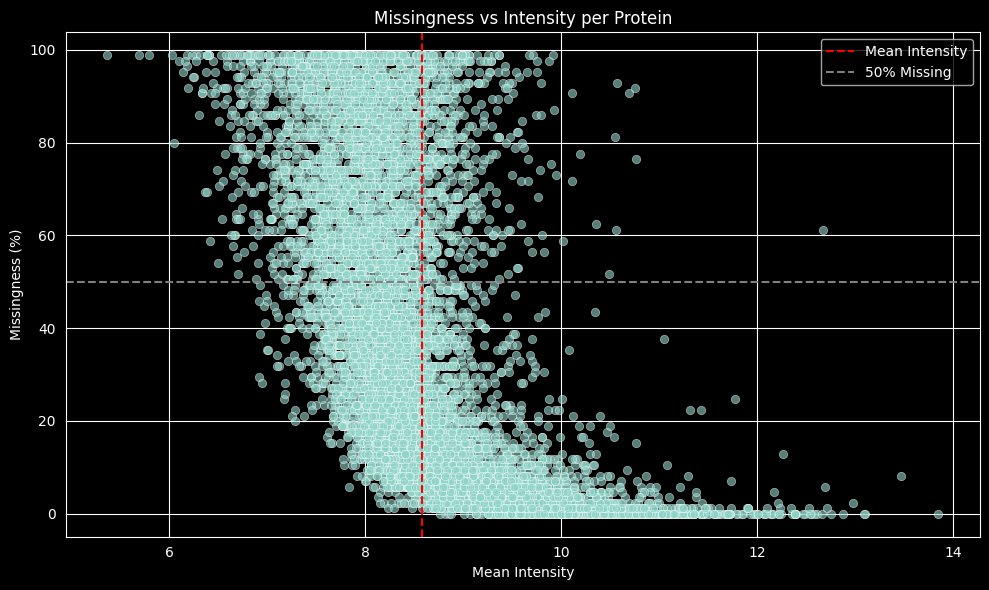

In [63]:

import seaborn as sns

# Compute mean intensity and missing % per protein
expression_data = tissue_data.iloc[:, 1:]
mean_intensity = expression_data.mean(axis=1)
missing_percent = expression_data.isna().sum(axis=1) / expression_data.shape[1] * 100
print(mean_intensity.shape)
# Combine into a DataFrame for plotting
diagnostic_df = pd.DataFrame({
    'mean_intensity': mean_intensity,
    'missing_percent': missing_percent
})

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df, x='mean_intensity', y='missing_percent', alpha=0.6)

# Add vertical line: mean of mean intensities
plt.axvline(diagnostic_df['mean_intensity'].mean(), color='red', linestyle='--', label='Mean Intensity')

# Add horizontal line at 50% missingness
plt.axhline(50, color='gray', linestyle='--', label='50% Missing')

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity per Protein')
plt.legend()
plt.tight_layout()
plt.show()


(5127,)


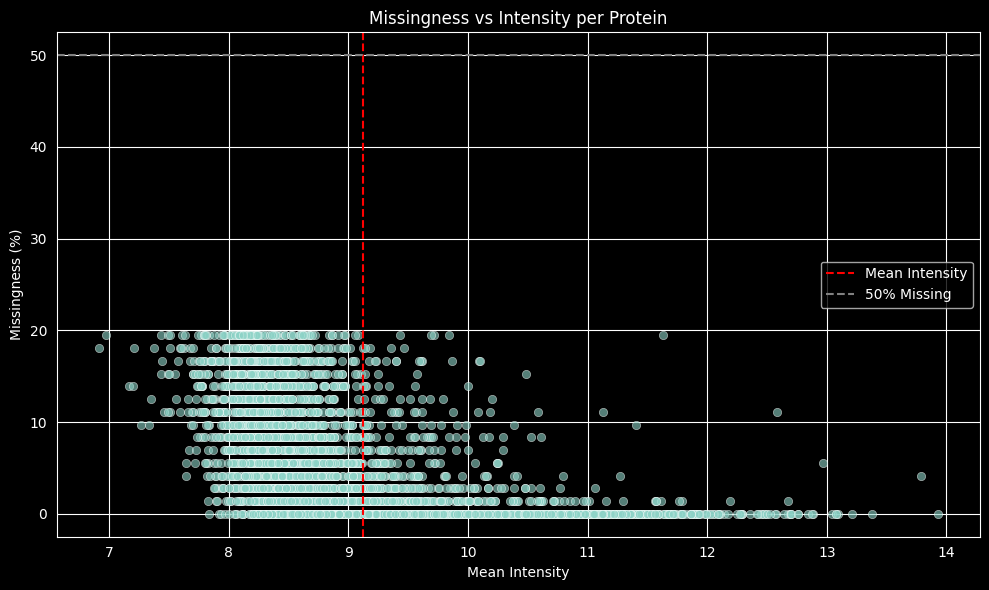

In [64]:
import seaborn as sns

# Compute mean intensity and missing % per protein
expression_data = tissue_data_filtered_final.iloc[:, 1:]
mean_intensity = expression_data.mean(axis=1)
missing_percent = expression_data.isna().sum(axis=1) / expression_data.shape[1] * 100
print(mean_intensity.shape)
# Combine into a DataFrame for plotting
diagnostic_df = pd.DataFrame({
    'mean_intensity': mean_intensity,
    'missing_percent': missing_percent
})

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df, x='mean_intensity', y='missing_percent', alpha=0.6)

# Add vertical line: mean of mean intensities
plt.axvline(diagnostic_df['mean_intensity'].mean(), color='red', linestyle='--', label='Mean Intensity')

# Add horizontal line at 50% missingness
plt.axhline(50, color='gray', linestyle='--', label='50% Missing')

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity per Protein')
plt.legend()
plt.tight_layout()
plt.show()

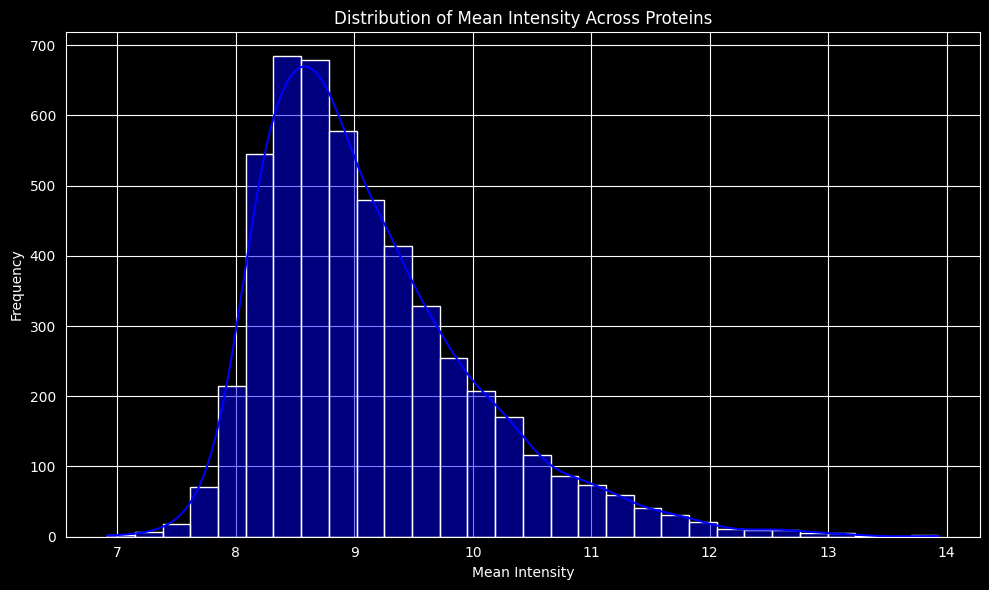

In [88]:

# Plot the histogram of mean intensity values
plt.figure(figsize=(10, 6))
sns.histplot(mean_intensity, kde=True, color='blue', bins=30)

# Add labels and title
plt.title('Distribution of Mean Intensity Across Proteins')
plt.xlabel('Mean Intensity')
plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()


#### Per cohort analysis

In [97]:
cohorts={
    'AAA':['S013','S021','S054','S066','S069','S092','S083','S072','S075','S094','S010','S040','S062','S005','S014','S034','S037','S078','S081','S092','S006','S093'],
    'AAA_Diabetes_Smoker':['S001','S029','S036','S047','S052','S060','S086','S076'],
    'AAA_Diabetes':['S002','S012','S020','S024','S031','S050'],
    'AAA_Diabetes_Metformin_Smoker':['S011','S025','S028','S051','S061','S082','S048','S032','S095'],
    'AAA_Smoker':['S004','S007','S015','S018','S044','S064','S065','S073','S077','S089','S090','S023','S030','S042','S059','S022','S038','S068','S085','S088','S096','S070','S017','S045','S049','S055','S057','S008','S016','S079','S080','S087','S091','S084','S039'],
    'Control': ['S003','S026','S027','S035','S041','S043','S046','S056','S058','S063','S071','S074','S019','S033','S053','S009','S067']
}
tissue_labels = {}
for cohort in cohorts.keys():
    for value in cohorts[cohort]:
        tissue_labels[value] = cohort

tissue_labels = pd.DataFrame(tissue_labels.items(),columns=['Sample','Cohort Name'])
tissue_labels.to_csv('tissue_labels.csv', index=False)
tissue_labels.head()

,Sample,Cohort Name
0,S013,AAA
1,S021,AAA
2,S054,AAA
3,S066,AAA
4,S069,AAA


In [98]:
print(len(tissue_labels))

96


In [99]:
tissue_labels = tissue_labels[tissue_labels['Sample'].isin(matched_samples)]
print(tissue_labels.head())
print(len(tissue_labels))

  Sample Cohort Name
0   S013         AAA
1   S021         AAA
2   S054         AAA
3   S066         AAA
4   S069         AAA
85


In [100]:
tissue_labels = tissue_labels.set_index("Sample")
tissue_labels = tissue_labels['Cohort Name']

In [105]:
tissue_data_1 = tissue_data.set_index("Genes")
expr_t = tissue_data_1.T
#print(expr_t.head())
print(expr_t.shape)
expr_t["cohort"] = tissue_labels

missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.drop(columns="cohort").isna().mean())
#print(missing_by_cohort.head())

missing_by_cohort = missing_by_cohort.T

(85, 9726)


/home/bmep/plalfken/tmp/ipykernel_691007/2877578801.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.drop(columns="cohort").isna().mean())


In [103]:
check = expr_t[expr_t['cohort'].isna()]
check.head(
)

,0,1,2,3,4,5,6,7,8,9,...,9717,9718,9719,9720,9721,9722,9723,9724,9725,cohort
Genes,SGCB,MECP2,C11orf68,UBR3,IPO9,MAPK1,QDPR,VPS51,POLE4,IPO5,...,CCR6,RWDD2B,DBNL,ADAMTS8,cRAP-ALDOA,API5,MALSU1,CDC42,SERPINB13,NaN


In [83]:
print(missing_by_cohort.head())

cohort       AAA  AAA_Diabetes  AAA_Diabetes_Metformin_Smoker  \
0       0.315789      0.000000                       0.142857   
1       0.052632      0.000000                       0.142857   
2       0.052632      0.000000                       0.142857   
3       0.421053      0.166667                       0.285714   
4       0.000000      0.000000                       0.000000   

cohort  AAA_Diabetes_Smoker  AAA_Smoker   Control  
0                       0.0    0.241379  0.071429  
1                       0.0    0.103448  0.000000  
2                       0.0    0.103448  0.071429  
3                       0.0    0.413793  0.285714  
4                       0.0    0.000000  0.000000  


In [106]:
#Accounted for cohort size
missingness_per_cohort = (
    expr_t
    .groupby('cohort')
    .apply(lambda df: df.isna().sum().sum() / df.drop(columns='cohort').size * 100)
)

print("Missingness percentage per cohort:")
print(missingness_per_cohort)


Missingness percentage per cohort:
cohort
AAA                              40.617417
AAA_Diabetes                     24.897183
AAA_Diabetes_Metformin_Smoker    41.331042
AAA_Diabetes_Smoker              24.717253
AAA_Smoker                       40.186442
Control                          35.522605
dtype: float64


/home/bmep/plalfken/tmp/ipykernel_691007/1443719485.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  expr_t


In [108]:
print(tissue_data_1.shape)

(9726, 85)


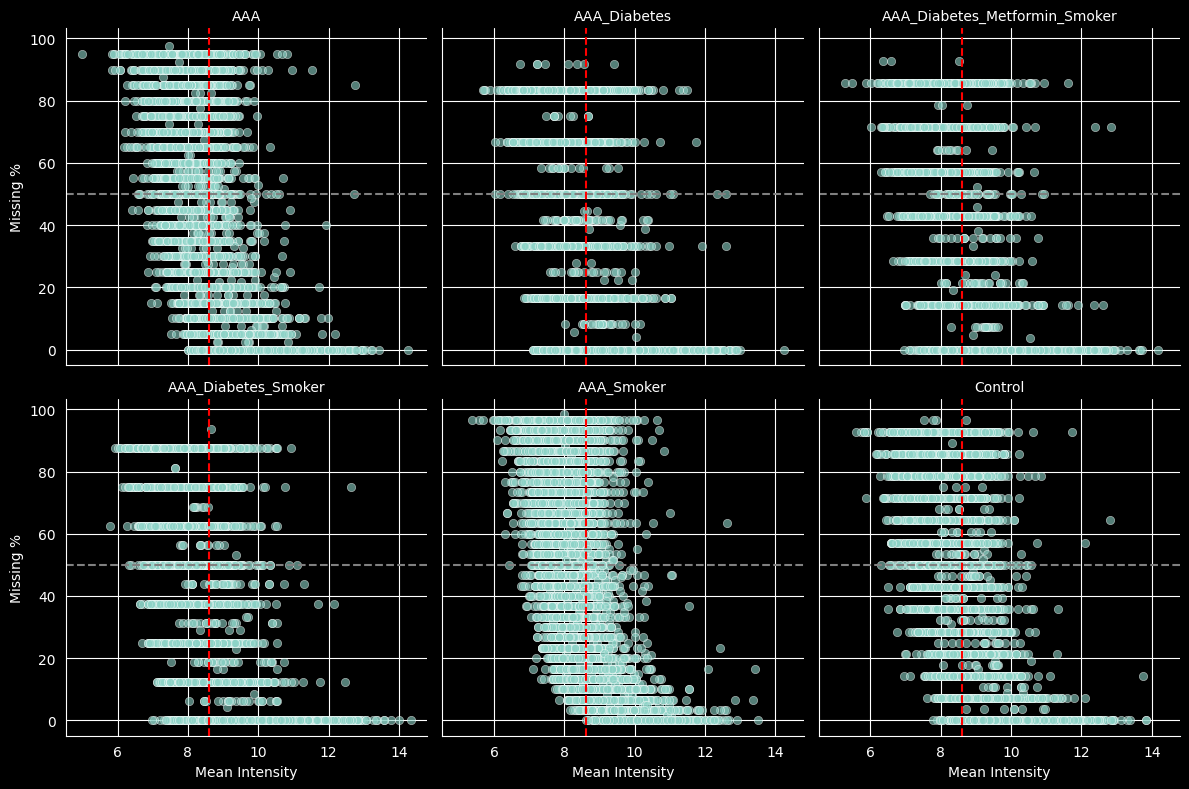

In [109]:
expression_T = tissue_data_1.T.copy().reset_index(drop=True)

expression_T['cohort'] = tissue_labels.values

long_df = expression_T.melt(id_vars='cohort', var_name='protein', value_name='intensity')

summary_df = (
    long_df
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

g = sns.FacetGrid(
    summary_df,
    col="cohort",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    ax.axhline(50, color='gray', linestyle='--')
    ax.axvline(summary_df['mean_intensity'].mean(), color='red', linestyle='--')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()

#### Check for MAR

### Imputation methods

##### MICE imputer


In [ ]:
from sklearn.impute import IterativeImputer

from sklearn.ensemble import ExtraTreesRegressor


gene_symbols = tissue_data_filtered_final.iloc[:, 0].to_numpy()


X = tissue_data_filtered_final.iloc[:, 1:].to_numpy().T.astype(np.float32)  # Transpose for MICE

# =============================================
# 2. Optimized MICE Configuration
# =============================================
imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    max_iter=20,
    tol=1e-3,
    n_nearest_features=25,
    initial_strategy="median",
    verbose=2,
    random_state=42
)

# =============================================
# 3. Perform MICE Imputation
# =============================================
print("Starting optimized MICE imputation...")
X_imputed = imputer.fit_transform(X)

# =============================================
# 4. Memory-Efficient Reconstruction
# =============================================
df_imputed = pd.DataFrame(
    X_imputed.T,
    columns=tissue_data_filtered_final.columns[1:],
    index=tissue_data_filtered_final.index
).astype(np.float32)

df_imputed.insert(0, 'Gene', gene_symbols)  # Reattach gene symbols

# =============================================
# 5. Save & Evaluate
# =============================================
df_imputed.to_csv("imputed_mice_optimized_cpt.csv", index=False)

missing_mask = np.isnan(X)

print(f"MICE completed in {imputer.n_iter_} iterations")

Starting optimized MICE imputation...
[IterativeImputer] Completing matrix with shape (72, 5127)
[IterativeImputer] Ending imputation round 1/20, elapsed time 890.09
[IterativeImputer] Change: 932.5496826171875, scaled tolerance: 0.01931314915418625 


##### KNN imputer

In [ ]:
from sklearn.impute import KNNImputer
# Grid search parameters
param_grid = {
    'n_neighbors': [10, 25, 50, 75, 100],
    'weights': ['uniform', 'distance']
}

# Initialize KNN imputer
knn_imputer = KNNImputer()

# Placeholder for stability results
stability_results = []

# Number of runs for stability test
n_runs = 10

for n_neighbors in param_grid['n_neighbors']:
    for weights in param_grid['weights']:
        print(f"Trying n_neighbors = {n_neighbors}, weights = {weights}...")

        # Set up the KNN imputer with the current parameters
        imputer = KNNImputer(n_neighbors=n_neighbors, metric='nan_euclidean', weights=weights)

        # Run the imputation multiple times for stability
        imputed_dfs = []
        for _ in range(n_runs):
            X_imputed = imputer.fit_transform(X)  # Assuming X is your input data

            # Store the imputed result for stability check
            imputed_dfs.append(X_imputed)

        # Calculate the variance across the runs
        imputed_dfs_array = np.array(imputed_dfs)
        variance = np.var(imputed_dfs_array, axis=0)  # Calculate variance across the runs

        # Store the variance and configuration in the results
        stability_results.append({
            'n_neighbors': n_neighbors,
            'weights': weights,
            'variance': np.mean(variance)  # Average variance across all features
        })

# Find the configuration with the minimum variance
best_config = min(stability_results, key=lambda x: x['variance'])

print(f"Best configuration (least variance): {best_config}")

# Apply the best imputer configuration
best_imputer = KNNImputer(n_neighbors=best_config['n_neighbors'], metric='nan_euclidean',
                          weights=best_config['weights'])

X_knn_optimized = best_imputer.fit_transform(X)

# Reconstruct DataFrame
df_knn_optimized = pd.DataFrame(X_knn_optimized.T, columns=tissue_data_filtered_final.columns[1:], index=tissue_data_filtered_final.index)
df_knn_optimized.insert(0, 'Gene', gene_symbols)

# Save the optimized result
df_knn_optimized.to_csv("imputed_knn_optimized_stability.csv", index=False)

##### Hyperimpute Imputation

In [ ]:
from hyperimpute.plugins.imputers import Imputers
from sklearn.datasets import load_iris
from hyperimpute.plugins.imputers import Imputers
from hyperimpute.utils.benchmarks import compare_models

imputers = Imputers()

imputers.list()

In [ ]:
proteins = tissue_data_filtered_final.iloc[:, 0]
X = tissue_data_filtered_final.iloc[:, 1:].copy()

X_transposed = X.T.copy()

imputer = Imputers().get("hyperimpute")

X_imputed = imputer.fit_transform(X_transposed)

X_final = X_imputed.T

final_imputed = pd.concat([proteins, pd.DataFrame(X_final, columns=X.columns)], axis=1)

final_imputed.to_csv("imputed_expression.csv", index=False)
print("✅ Imputation complete! Saved as imputed_expression.csv.")

In [ ]:
print(f"Selected imputer: {imputer.name()}")

In [ ]:
protein_list = tissue_data_filtered_final.iloc[:, 0].tolist()

# Save the protein list to a CSV file
protein_list_df = pd.DataFrame(protein_list, columns=["Protein"])
protein_list_df.to_csv("protein_list_PRPT.csv", index=False)